<a href="https://colab.research.google.com/github/sithmiUmeshika/23UG1-0078/blob/main/CCS4354_OGBN_Arxiv_GNN_Coursework_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

PyTorch Version: 2.11.0+cpu
CUDA Available: False
Using Device: cpu


In [ ]:
!pip install -q -U ogb torch-geometric streamlit scipy scikit-learn networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.3 MB/s eta 0:00:00


# CCS4354 – Tensors and Graphs Coursework
## Graph Neural Network-Based Node Classification on OGBN-Arxiv

In [ ]:
import os
import json
import random
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import networkx as nx

from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.utils import degree, to_undirected

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.decomposition import PCA

## Reproducibility Setup

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


A fixed random seed was used to improve the reproducibility of model initialization and experimental results.

# Task 01 – Tensor Fundamentals

## 1.1 Tensor Creation

In [ ]:
# Creating a 1D tensor
tensor_1d = torch.tensor([1, 2, 3, 4, 5])

# Creating a 2D tensor
tensor_2d = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

# Creating tensors using built-in functions
zeros_tensor = torch.zeros((2, 3))
ones_tensor = torch.ones((2, 3))

print("1D Tensor:")
print(tensor_1d)

print("\n2D Tensor:")
print(tensor_2d)

print("\nZeros Tensor:")
print(zeros_tensor)

print("\nOnes Tensor:")
print(ones_tensor)

1D Tensor:
tensor([1, 2, 3, 4, 5])

2D Tensor:
tensor([[1, 2, 3],
        [4, 5, 6]])

Zeros Tensor:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Ones Tensor:
tensor([[1., 1., 1.],
        [1., 1., 1.]])


### Explanation

A tensor is a multidimensional data structure used to store numerical values. PyTorch tensors are similar to NumPy arrays, but they can also be processed efficiently using GPUs.

In this example, `torch.tensor()` is used to create one-dimensional and two-dimensional tensors from existing numerical values. The `torch.zeros()` and `torch.ones()` functions are used to create tensors initialized entirely with zeros and ones. Tensor creation is important in deep learning because input features, model parameters, and intermediate computations are represented as tensors.

## 1.2 Tensor Indexing

In [ ]:
x = torch.tensor([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

print("Original Tensor:")
print(x)

print("\nFirst Row:")
print(x[0])

print("\nElement at row 2, column 3:")
print(x[1, 2])

print("\nSecond Column:")
print(x[:, 1])

Original Tensor:
tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])

First Row:
tensor([10, 20, 30])

Element at row 2, column 3:
tensor(60)

Second Column:
tensor([20, 50, 80])


### Explanation

Tensor indexing is used to access specific elements, rows, columns, or subsets of a tensor. For example, `x[0]` selects the first row, `x[1, 2]` selects one specific element, and `x[:, 1]` selects the second column from all rows. Indexing is important when selecting particular samples, features, or subsets of data during machine learning operations.

## 1.3 Tensor Reshaping

In [ ]:
x = torch.arange(12)

print("Original Tensor:")
print(x)
print("Original Shape:", x.shape)

reshaped = x.reshape(3, 4)

print("\nReshaped Tensor:")
print(reshaped)
print("New Shape:", reshaped.shape)

Original Tensor:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Original Shape: torch.Size([12])

Reshaped Tensor:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
New Shape: torch.Size([3, 4])


### Explanation

Tensor reshaping changes the dimensions of a tensor without changing the underlying values. Here, a one-dimensional tensor containing 12 values is reshaped into a `3 × 4` tensor. Reshaping is commonly required in neural networks when data must be converted into the dimensions expected by a particular layer while preserving the same total number of elements.

## 1.4 Matrix Multiplication

In [ ]:
A = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

B = torch.tensor([
    [5.0, 6.0],
    [7.0, 8.0]
])

C = torch.matmul(A, B)

print("Matrix A:")
print(A)

print("\nMatrix B:")
print(B)

print("\nA × B:")
print(C)

Matrix A:
tensor([[1., 2.],
        [3., 4.]])

Matrix B:
tensor([[5., 6.],
        [7., 8.]])

A × B:
tensor([[19., 22.],
        [43., 50.]])


### Explanation

Matrix multiplication combines two compatible matrices using row-by-column multiplication. For two matrices to be multiplied, the number of columns in the first matrix must equal the number of rows in the second matrix.

In this example, two `2 × 2` matrices are multiplied using `torch.matmul()`, producing another `2 × 2` matrix. Matrix multiplication is a fundamental operation in neural networks because input features are repeatedly multiplied by learned weight matrices during forward propagation.

## 1.5 Tensor Broadcasting

In [ ]:
matrix = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

vector = torch.tensor([10, 20, 30])

result = matrix + vector

print("Matrix:")
print(matrix)

print("\nVector:")
print(vector)

print("\nBroadcasting Result:")
print(result)

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])

Vector:
tensor([10, 20, 30])

Broadcasting Result:
tensor([[11, 22, 33],
        [14, 25, 36]])


### Explanation

Broadcasting allows PyTorch to perform operations between tensors with different but compatible shapes without manually copying the smaller tensor. In this example, the vector with shape `(3,)` is automatically applied to each row of the matrix with shape `(2, 3)`.

This makes tensor operations more memory-efficient and allows concise mathematical operations when working with batches of data.

## 1.6 Tensor Aggregation Operations

In [ ]:
x = torch.tensor([2.0, 4.0, 6.0, 8.0, 10.0])

print("Tensor:", x)
print("Sum:", torch.sum(x))
print("Mean:", torch.mean(x))
print("Maximum:", torch.max(x))
print("Minimum:", torch.min(x))
print("Standard Deviation:", torch.std(x))

Tensor: tensor([ 2.,  4.,  6.,  8., 10.])
Sum: tensor(30.)
Mean: tensor(6.)
Maximum: tensor(10.)
Minimum: tensor(2.)
Standard Deviation: tensor(3.1623)


### Explanation

Tensor aggregation operations summarize multiple tensor values into useful statistical quantities. In this example, `sum`, `mean`, `maximum`, `minimum`, and `standard deviation` are calculated.

Aggregation operations are commonly used in data analysis and machine learning to summarize feature values, calculate statistics, and reduce multidimensional information into smaller representations.

## 1.7 GPU Tensor Operations

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpu_tensor = torch.tensor(
    [1.0, 2.0, 3.0, 4.0],
    device=device
)

result = gpu_tensor * 2

print("Device:", device)
print("Tensor:", gpu_tensor)
print("Result:", result)

Device: cpu
Tensor: tensor([1., 2., 3., 4.])
Result: tensor([2., 4., 6., 8.])


### Explanation

PyTorch tensors can be transferred to CUDA-compatible GPUs to accelerate numerical computations. The code first checks whether CUDA is available and selects either the GPU or CPU automatically.

The tensor is created directly on the selected device and a multiplication operation is performed on the same device. GPU acceleration is particularly useful for large-scale deep learning and Graph Neural Network training because many tensor operations can be executed in parallel.

# Task 02 – Graph Representation and Analysis

## 2.1 Loading and Verifying the Prepared OGBN-Arxiv Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os

print("Searching for ogbn_arxiv_prepared.pt ...\n")

for root, dirs, files in os.walk("/content/drive"):
    for file in files:
        if "ogbn_arxiv_prepared" in file.lower():
            print("FOUND:", os.path.join(root, file))

Searching for ogbn_arxiv_prepared.pt ...

FOUND: /content/drive/MyDrive/CCS4354_Tensors_and_Graphs/ogbn_arxiv_prepared.pt


In [5]:
import torch

prepared_path = "/content/drive/MyDrive/CCS4354_Tensors_and_Graphs/ogbn_arxiv_prepared.pt"

prepared_data = torch.load(
    prepared_path,
    map_location="cpu",
    weights_only=False
)

print("Prepared OGBN-Arxiv dataset loaded successfully!")
print("Loaded object type:", type(prepared_data))

if isinstance(prepared_data, dict):
    print("\nAvailable keys:")
    for key in prepared_data.keys():
        print("-", key)

Prepared OGBN-Arxiv dataset loaded successfully!
Loaded object type: <class 'dict'>

Available keys:
- data
- train_idx
- valid_idx
- test_idx
- feature_mean
- feature_std
- num_classes


In [6]:
# Extract prepared OGBN-Arxiv components

data = prepared_data["data"]

train_idx = prepared_data["train_idx"]
valid_idx = prepared_data["valid_idx"]
test_idx = prepared_data["test_idx"]

feature_mean = prepared_data["feature_mean"]
feature_std = prepared_data["feature_std"]

num_classes = int(prepared_data["num_classes"])

print("=" * 60)
print("OGBN-ARXIV DATASET OVERVIEW")
print("=" * 60)

print("Number of Nodes       :", data.num_nodes)
print("Number of Edges       :", data.num_edges)
print("Number of Features    :", data.num_features)
print("Number of Classes     :", num_classes)

print("\nFeature Matrix Shape  :", data.x.shape)
print("Edge Index Shape      :", data.edge_index.shape)
print("Label Shape           :", data.y.shape)

if hasattr(data, "node_year"):
    print("Node Year Shape       :", data.node_year.shape)

print("\nFeature Data Type     :", data.x.dtype)
print("Edge Index Data Type  :", data.edge_index.dtype)
print("Label Data Type       :", data.y.dtype)

OGBN-ARXIV DATASET OVERVIEW
Number of Nodes       : 169343
Number of Edges       : 1166243
Number of Features    : 128
Number of Classes     : 40

Feature Matrix Shape  : torch.Size([169343, 128])
Edge Index Shape      : torch.Size([2, 1166243])
Label Shape           : torch.Size([169343, 1])
Node Year Shape       : torch.Size([169343, 1])

Feature Data Type     : torch.float32
Edge Index Data Type  : torch.int64
Label Data Type       : torch.int64


### Dataset Description

The OGBN-Arxiv dataset is a directed citation network of computer science research papers. Each node represents a research paper, while each directed edge represents a citation relationship between two papers.

The dataset contains 169,343 research-paper nodes and 1,166,243 citation edges. Each paper is represented by a 128-dimensional feature vector derived from its title and abstract. The target variable contains 40 research subject categories.

Therefore, the learning problem is a multi-class node classification task in which the objective is to predict the research category of each paper using both its node features and citation relationships.

## 2.2 Edge List Representation

In PyTorch Geometric, graph connections are represented using the `edge_index` tensor. The first row contains the source nodes and the second row contains the target nodes.

For the OGBN-Arxiv citation graph, a directed edge from paper A to paper B means that paper A cites paper B.

In [8]:
import pandas as pd

# Convert PyTorch Geometric edge_index into an edge-list table

edge_list = data.edge_index.t().cpu().numpy()

edge_df = pd.DataFrame(
    edge_list,
    columns=["Source_Node", "Target_Node"]
)

print("First 10 Citation Edges:")
print(edge_df.head(10))

print("\nTotal Number of Edges:", len(edge_df))

print("\nEdge Index Shape:", data.edge_index.shape)
print("Edge List Shape:", edge_df.shape)

First 10 Citation Edges:
   Source_Node  Target_Node
0       104447        13091
1        15858        47283
2       107156        69161
3       107156       136440
4       107156       107366
5       107156       158460
6       141536        90124
7       141536       121740
8       141536       122427
9       141536       161023

Total Number of Edges: 1166243

Edge Index Shape: torch.Size([2, 1166243])
Edge List Shape: (1166243, 2)


### Interpretation

Each row of the edge list represents one directed citation relationship between two research papers. `Source_Node` represents the citing paper, while `Target_Node` represents the paper being cited.

The edge list contains 1,166,243 rows, which is equal to the total number of directed edges in the graph. This representation is memory-efficient for a sparse graph such as OGBN-Arxiv because only existing citation relationships are stored instead of constructing a large dense adjacency matrix containing all possible node pairs.

## 2.3 Sample Subgraph Visualization

A small portion of the OGBN-Arxiv citation network is visualized to demonstrate the relationships between research papers. Since the complete graph contains more than one million edges, only a small sample is used to produce a clear and readable visualization.

Sample Subgraph Nodes: 144
Sample Subgraph Edges: 100


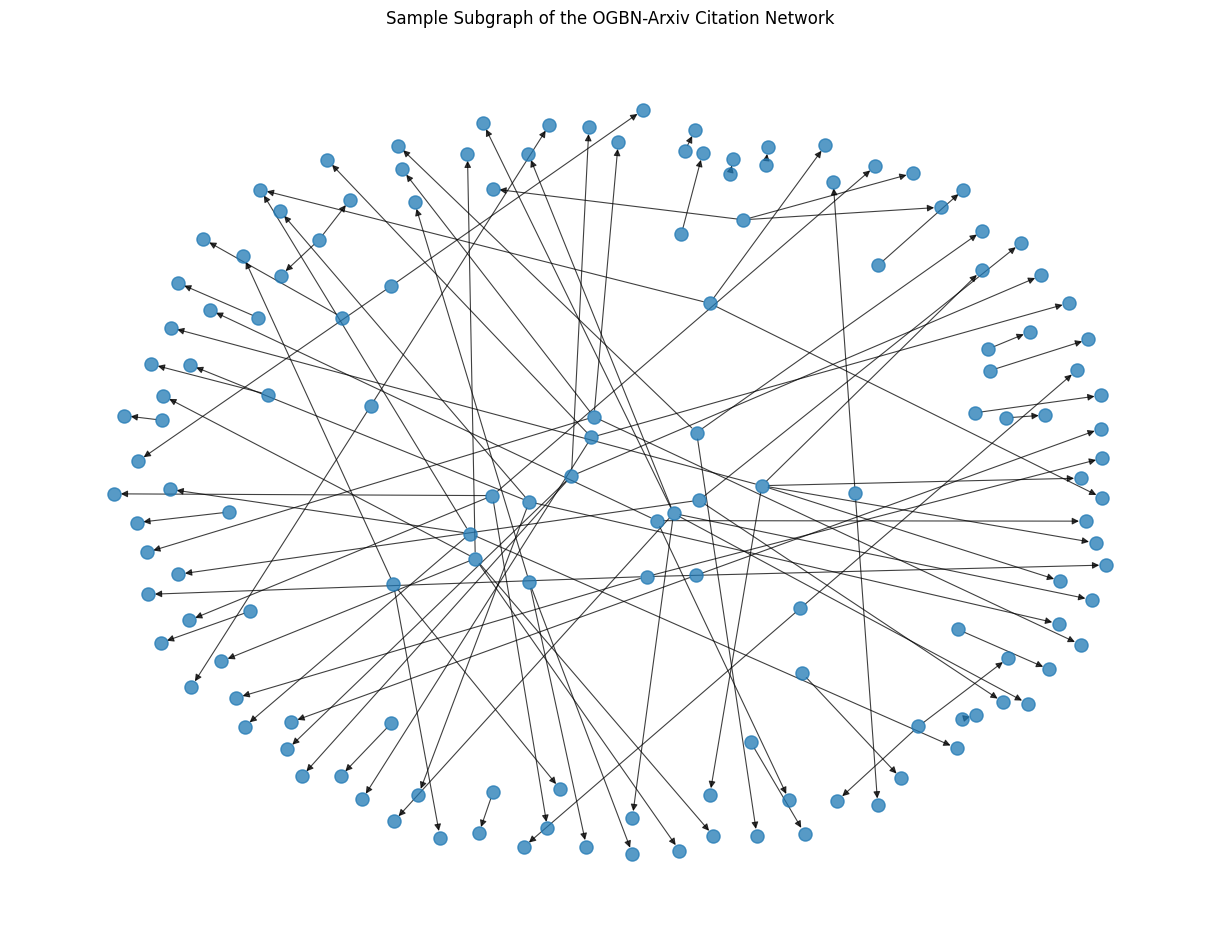

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Select a small sample of directed citation edges
sample_edges = (
    data.edge_index[:, :100]
    .t()
    .cpu()
    .numpy()
)

# Create a directed NetworkX graph
G_sample = nx.DiGraph()
G_sample.add_edges_from(sample_edges)

print("Sample Subgraph Nodes:", G_sample.number_of_nodes())
print("Sample Subgraph Edges:", G_sample.number_of_edges())

# Reproducible layout
pos = nx.spring_layout(
    G_sample,
    seed=42
)

plt.figure(figsize=(12, 9))

nx.draw(
    G_sample,
    pos=pos,
    node_size=90,
    arrows=True,
    with_labels=False,
    alpha=0.75,
    width=0.8
)

plt.title(
    "Sample Subgraph of the OGBN-Arxiv Citation Network"
)

plt.savefig(
    "sample_subgraph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The sample subgraph illustrates the directed citation structure of OGBN-Arxiv. Each node represents a research paper, while each arrow represents a citation relationship between two papers.

The visualization shows that papers are connected through different local citation patterns, with some nodes having several incoming or outgoing links. These relationships provide structural information in addition to the paper features, which is one of the main reasons Graph Neural Networks are suitable for this node classification task.

## 2.4 Node Feature Analysis

Each node in the OGBN-Arxiv dataset represents a research paper and contains a 128-dimensional numerical feature vector derived from the paper's title and abstract. These node features provide semantic information that is used together with citation relationships during Graph Neural Network training.

In [10]:
# Analyze node features

features = data.x

print("=" * 60)
print("NODE FEATURE ANALYSIS")
print("=" * 60)

print("Feature Matrix Shape :", features.shape)
print("Feature Data Type    :", features.dtype)

print("\nFirst Paper Feature Vector:")
print(features[0])

print("\nFeature Statistics")
print("Overall Mean               :", features.mean().item())
print("Overall Standard Deviation :", features.std().item())
print("Minimum Feature Value      :", features.min().item())
print("Maximum Feature Value      :", features.max().item())

print("\nMissing Values:", torch.isnan(features).sum().item())

NODE FEATURE ANALYSIS
Feature Matrix Shape : torch.Size([169343, 128])
Feature Data Type    : torch.float32

First Paper Feature Vector:
tensor([ 0.2999, -0.6273,  1.0739,  0.3679,  0.7230, -1.4576, -0.7564,  0.8078,
        -1.0600,  0.5206, -0.8553,  1.3118, -1.7179,  0.5034,  0.6057, -1.0502,
         0.7803,  1.2447,  0.3681,  0.5304, -1.6090,  1.1686, -2.0586, -0.0444,
         0.6133,  1.4865, -0.8628,  1.1326,  0.2771, -0.0658, -0.5897, -1.0260,
         0.5194,  1.7482,  0.2574,  0.2166,  1.4742,  0.1911,  0.0711, -1.3710,
         0.6372,  0.7984, -2.3059, -0.5634, -0.6564,  1.6689, -1.5089, -2.1973,
         0.8662,  0.9015, -0.4186, -0.5844,  0.6220,  0.5857, -0.8030,  0.1334,
         1.0135,  1.0473, -0.8172,  0.5623, -0.6338, -0.9150,  0.5139, -0.4595,
        -1.4916,  0.6712,  2.5153, -2.2661, -1.3248,  0.6133, -0.2410,  0.4921,
        -0.0264,  0.5904,  0.5575, -1.3004,  0.0339,  1.2710,  0.1715,  0.3935,
         0.5862, -0.7835,  0.5393,  2.6883, -0.7731, -0.0044, -

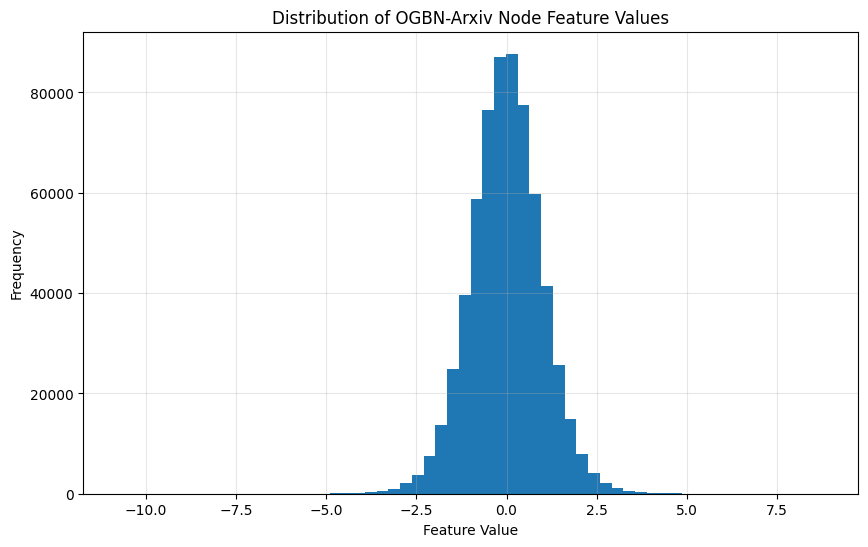

In [11]:
# Visualize the distribution of node feature values

feature_sample = (
    features[:5000]
    .cpu()
    .numpy()
    .flatten()
)

plt.figure(figsize=(10, 6))

plt.hist(
    feature_sample,
    bins=60
)

plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.title(
    "Distribution of OGBN-Arxiv Node Feature Values"
)
plt.grid(alpha=0.3)

plt.savefig(
    "node_feature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The node feature matrix has a shape of `(169343, 128)`, meaning that each of the 169,343 research papers is represented by 128 numerical features. Each row corresponds to one paper, while each column represents one feature dimension derived from the paper's textual information.

The feature values are stored as floating-point numbers and no missing values are present in the feature matrix. This allows the features to be used directly during subsequent preprocessing and GNN training.

The feature-distribution visualization provides an overview of the numerical range and concentration of the node attributes. These semantic node features, together with citation-based neighborhood information, provide the two main sources of information used by the GNN models.

## 2.5 Degree Distribution Analysis

Node degree measures how many graph connections are associated with a node. Since OGBN-Arxiv is a directed citation network, two degree measures are considered:

- **Out-degree**: the number of papers cited by a research paper.
- **In-degree**: the number of citation links received by a research paper from other papers.

Analyzing degree distributions helps reveal the connectivity structure of the citation network.

In [12]:
from torch_geometric.utils import degree

# Calculate in-degree and out-degree
num_nodes = data.num_nodes

out_degrees = degree(
    data.edge_index[0],
    num_nodes=num_nodes,
    dtype=torch.long
)

in_degrees = degree(
    data.edge_index[1],
    num_nodes=num_nodes,
    dtype=torch.long
)

print("=" * 60)
print("DEGREE ANALYSIS")
print("=" * 60)

print("Average Out-Degree :", out_degrees.float().mean().item())
print("Average In-Degree  :", in_degrees.float().mean().item())

print("\nMaximum Out-Degree :", out_degrees.max().item())
print("Maximum In-Degree  :", in_degrees.max().item())

print("\nMinimum Out-Degree :", out_degrees.min().item())
print("Minimum In-Degree  :", in_degrees.min().item())

print("\nNodes with Zero Out-Degree :", (out_degrees == 0).sum().item())
print("Nodes with Zero In-Degree  :", (in_degrees == 0).sum().item())

DEGREE ANALYSIS
Average Out-Degree : 6.886868476867676
Average In-Degree  : 6.886868476867676

Maximum Out-Degree : 436
Maximum In-Degree  : 13155

Minimum Out-Degree : 0
Minimum In-Degree  : 0

Nodes with Zero Out-Degree : 17440
Nodes with Zero In-Degree  : 62006


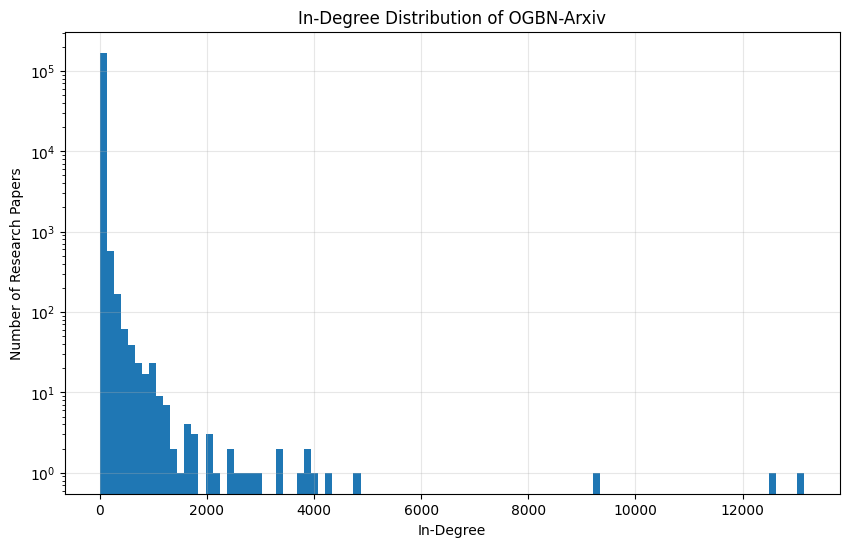

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    in_degrees.cpu().numpy(),
    bins=100
)

plt.xlabel("In-Degree")
plt.ylabel("Number of Research Papers")
plt.title(
    "In-Degree Distribution of OGBN-Arxiv"
)

plt.yscale("log")
plt.grid(alpha=0.3)

plt.savefig(
    "in_degree_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

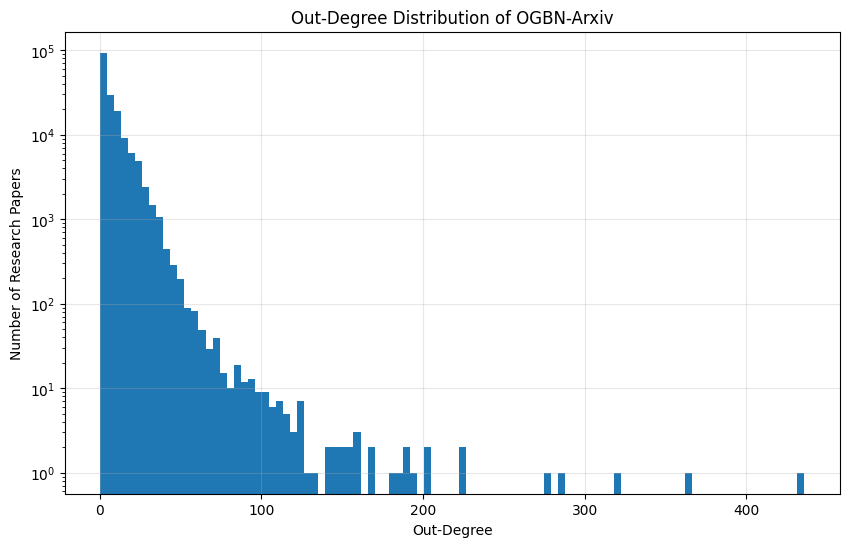

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    out_degrees.cpu().numpy(),
    bins=100
)

plt.xlabel("Out-Degree")
plt.ylabel("Number of Research Papers")
plt.title(
    "Out-Degree Distribution of OGBN-Arxiv"
)

plt.yscale("log")
plt.grid(alpha=0.3)

plt.savefig(
    "out_degree_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The average in-degree and average out-degree are approximately the same because every directed citation edge contributes once to the out-degree of the source paper and once to the in-degree of the target paper.

The degree distributions are highly skewed. Most research papers have relatively few citation connections, while a much smaller number of papers have very large degree values.

The maximum in-degree is much larger than the maximum out-degree, indicating that some papers receive citations from a very large number of other papers. These highly cited papers act as important hubs within the citation network.

The long-tailed degree distributions demonstrate that OGBN-Arxiv has a non-uniform graph structure. This is important for Graph Neural Networks because nodes can receive information from neighborhoods with very different sizes and connectivity patterns.

In [15]:
top_k = 10

top_in_degree_values, top_in_degree_nodes = torch.topk(
    in_degrees,
    k=top_k
)

top_degree_df = pd.DataFrame({
    "Node_ID": top_in_degree_nodes.cpu().numpy(),
    "In_Degree": top_in_degree_values.cpu().numpy()
})

print("Top 10 Most Highly Cited Nodes:")
display(top_degree_df)

Top 10 Most Highly Cited Nodes:


,Node_ID,In_Degree
0,1353,13155
1,67166,12527
2,25208,9244
3,69794,4779
4,93649,4238
5,115359,4033
6,22035,3861
7,133376,3844
8,106699,3737
9,166425,3407


## 2.6 Graph Density Analysis

Graph density measures how many edges exist in a graph compared with the maximum possible number of edges.

For a directed graph without self-loops, density is calculated as:

\[
\text{Density} = \frac{E}{N(N-1)}
\]

where:

- \(E\) = number of directed edges
- \(N\) = number of nodes

In [16]:
# Calculate directed graph density

N = data.num_nodes
E = data.num_edges

density = E / (N * (N - 1))

print("=" * 60)
print("GRAPH DENSITY ANALYSIS")
print("=" * 60)

print("Number of Nodes :", N)
print("Number of Edges :", E)
print("Graph Density   :", density)
print("Graph Density (%) :", density * 100)

GRAPH DENSITY ANALYSIS
Number of Nodes : 169343
Number of Edges : 1166243
Graph Density   : 4.066840277668502e-05
Graph Density (%) : 0.004066840277668502


### Interpretation

The calculated graph density is approximately \(4.07 \times 10^{-5}\), which is very close to zero.

This indicates that OGBN-Arxiv is a highly sparse graph. Although the graph contains more than 1.16 million citation edges, only a very small fraction of all theoretically possible directed paper-to-paper connections actually exist.

This sparsity is typical of large citation networks because each research paper cites only a small subset of all available papers. A sparse edge-list representation is therefore much more memory-efficient than constructing a full dense adjacency matrix.

## 2.7 Connected Component Analysis

Connected component analysis examines how nodes are grouped according to graph connectivity.

Because OGBN-Arxiv is a directed graph, two types of connectivity are considered:

- **Weakly connected component:** nodes are treated as connected when edge directions are ignored.
- **Strongly connected component:** every node in the component must be reachable from every other node while preserving edge direction.

In [18]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
import numpy as np

# Convert the directed edge list to a SciPy sparse adjacency matrix

src = data.edge_index[0].cpu().numpy()
dst = data.edge_index[1].cpu().numpy()

adjacency = coo_matrix(
    (
        np.ones(len(src), dtype=np.uint8),
        (src, dst)
    ),
    shape=(data.num_nodes, data.num_nodes)
).tocsr()

print("Sparse adjacency matrix created successfully.")
print("Adjacency Shape:", adjacency.shape)
print("Stored Connections:", adjacency.nnz)

Sparse adjacency matrix created successfully.
Adjacency Shape: (169343, 169343)
Stored Connections: 1166243


In [19]:
# Weakly connected components

num_weak_components, weak_labels = connected_components(
    adjacency,
    directed=True,
    connection="weak"
)

# Strongly connected components

num_strong_components, strong_labels = connected_components(
    adjacency,
    directed=True,
    connection="strong"
)

# Component sizes

weak_sizes = np.bincount(weak_labels)
strong_sizes = np.bincount(strong_labels)

print("=" * 60)
print("CONNECTED COMPONENT ANALYSIS")
print("=" * 60)

print(
    "Number of Weakly Connected Components :",
    num_weak_components
)

print(
    "Largest Weakly Connected Component    :",
    weak_sizes.max()
)

print(
    "\nNumber of Strongly Connected Components :",
    num_strong_components
)

print(
    "Largest Strongly Connected Component    :",
    strong_sizes.max()
)

CONNECTED COMPONENT ANALYSIS
Number of Weakly Connected Components : 1
Largest Weakly Connected Component    : 169343

Number of Strongly Connected Components : 141223
Largest Strongly Connected Component    : 23164


### Interpretation

The OGBN-Arxiv graph contains only **one weakly connected component**, and its largest weak component contains all **169,343 nodes**. This means that if citation directions are ignored, every research paper belongs to one overall connected citation network.

In contrast, the graph contains **141,223 strongly connected components**. This much larger number indicates that mutual reachability is highly limited when citation direction is preserved.

This behaviour is reasonable for a citation network because citations are directional and usually follow the chronological development of research. A newer paper may cite an older paper, but the older paper cannot normally cite the newer paper. Therefore, the graph is globally connected in a weak sense while being highly fragmented under strong directed connectivity.

## 2.8 Class Distribution Analysis

The distribution of target classes is analyzed to determine whether all research categories are represented equally. This is important because class imbalance can influence model evaluation and may cause accuracy alone to provide an incomplete view of model performance.

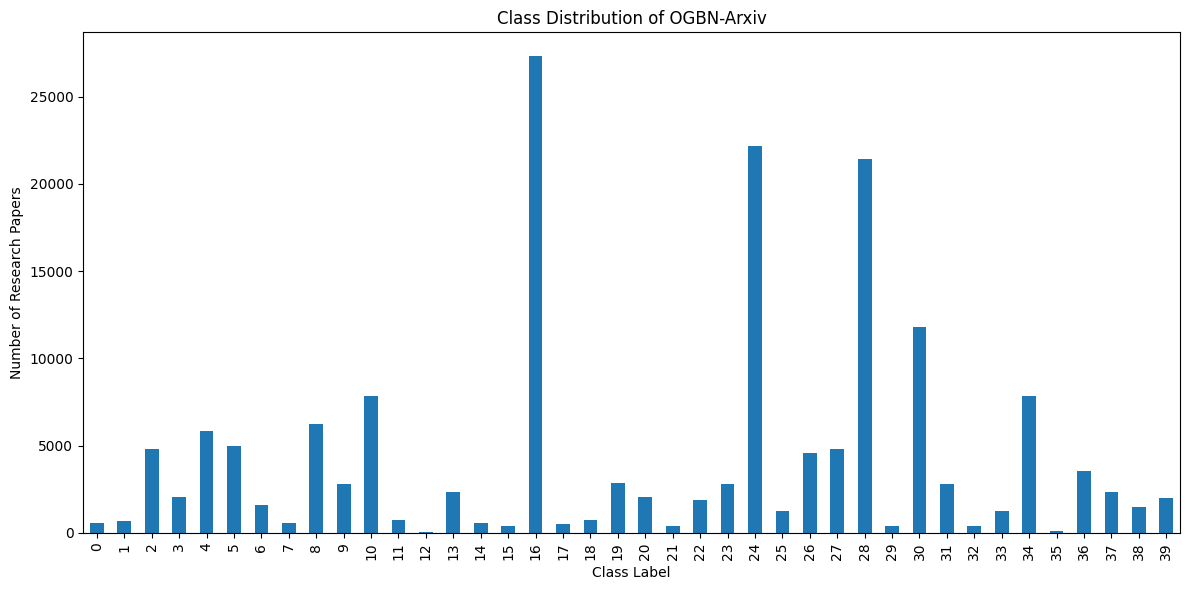

Number of Classes : 40
Smallest Class Size: 29
Largest Class Size : 27321


In [20]:
labels = data.y.squeeze().cpu().numpy()

class_counts = (
    pd.Series(labels)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

class_counts.plot(
    kind="bar"
)

plt.xlabel("Class Label")
plt.ylabel("Number of Research Papers")
plt.title(
    "Class Distribution of OGBN-Arxiv"
)

plt.tight_layout()

plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Number of Classes :", len(class_counts))
print("Smallest Class Size:", class_counts.min())
print("Largest Class Size :", class_counts.max())

### Interpretation

The class distribution is imbalanced because some research categories contain considerably more papers than others.

This means that overall accuracy alone may not fully reflect model performance, especially for minority classes. Therefore, later evaluation should also consider precision, recall, weighted F1 score, and macro F1 score in addition to accuracy.

## 2.9 Task 02 Summary

The OGBN-Arxiv graph contains 169,343 research-paper nodes, 1,166,243 directed citation edges, 128-dimensional node features, and 40 research categories.

The graph is highly sparse and has strongly skewed degree distributions, with a small number of highly connected citation hubs. Connected component analysis shows that the entire network forms one weakly connected component, while directed strong connectivity is highly fragmented.

The combination of semantic node features and non-uniform citation relationships provides a suitable foundation for Graph Neural Network-based node classification.

# Task 03 – Graph Data Preparation

The OGBN-Arxiv data is prepared for Graph Neural Network training by extracting the node features and labels, verifying the official dataset splits, checking data quality, normalizing the node features using training-set statistics only, and preparing the graph structure for GNN message passing.

## 3.1 Loading Node Features and Labels

The node feature matrix and target labels are extracted from the prepared OGBN-Arxiv graph. Each node represents one research paper, each node contains 128 numerical features, and the target label identifies one of the 40 research categories.

In [21]:
# Extract node features and labels

X = data.x.float()
y = data.y.view(-1).long()

print("=" * 60)
print("NODE FEATURES AND LABELS")
print("=" * 60)

print("Feature Matrix Shape :", X.shape)
print("Label Vector Shape   :", y.shape)

print("\nFeature Data Type :", X.dtype)
print("Label Data Type   :", y.dtype)

print("\nNumber of Nodes    :", X.shape[0])
print("Features per Node  :", X.shape[1])

print("Minimum Label      :", y.min().item())
print("Maximum Label      :", y.max().item())
print("Unique Classes     :", torch.unique(y).numel())

NODE FEATURES AND LABELS
Feature Matrix Shape : torch.Size([169343, 128])
Label Vector Shape   : torch.Size([169343])

Feature Data Type : torch.float32
Label Data Type   : torch.int64

Number of Nodes    : 169343
Features per Node  : 128
Minimum Label      : 0
Maximum Label      : 39
Unique Classes     : 40


### Interpretation

The feature matrix contains 169,343 rows and 128 columns. Therefore, each research paper is represented by a 128-dimensional numerical feature vector. The label vector contains one integer class label for each node.

The labels range from 0 to 39, confirming that the dataset contains 40 research categories. Features are stored as floating-point values, while the labels are converted to integer values because they will later be used with a multi-class classification loss function.

## 3.2 Data Quality and Integrity Checks

Before preprocessing, the features and labels are checked for missing or invalid numerical values. The number of feature rows is also verified against the number of labels to ensure that each paper has exactly one target label.

In [22]:
# Check data quality

nan_features = torch.isnan(X).sum().item()
inf_features = torch.isinf(X).sum().item()

nan_labels = torch.isnan(y.float()).sum().item()
inf_labels = torch.isinf(y.float()).sum().item()

print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("NaN Values in Features :", nan_features)
print("Infinite Feature Values:", inf_features)

print("\nNaN Values in Labels    :", nan_labels)
print("Infinite Label Values  :", inf_labels)

print(
    "\nFeature/Label Node Count Match:",
    X.shape[0] == y.shape[0]
)

print(
    "All Feature Values Finite:",
    torch.isfinite(X).all().item()
)

DATA QUALITY CHECK
NaN Values in Features : 0
Infinite Feature Values: 0

NaN Values in Labels    : 0
Infinite Label Values  : 0

Feature/Label Node Count Match: True
All Feature Values Finite: True


### Interpretation

No missing or infinite values are present in the feature matrix or target labels. The feature and label tensors also contain the same number of nodes. Therefore, no missing-value imputation or row removal is required before model training.

## 3.3 Training, Validation and Test Splits

The train, validation, and test node indices stored in the prepared OGBN-Arxiv data are retained instead of generating a new random split. This preserves the predefined experimental split used by the prepared dataset and ensures that the same nodes are used consistently throughout training and evaluation.

In [23]:
# Load the prepared train, validation and test indices

train_idx = prepared_data["train_idx"].view(-1).long()
valid_idx = prepared_data["valid_idx"].view(-1).long()
test_idx = prepared_data["test_idx"].view(-1).long()

total_split_nodes = (
    len(train_idx)
    + len(valid_idx)
    + len(test_idx)
)

print("=" * 60)
print("DATASET SPLITS")
print("=" * 60)

print("Training Nodes   :", len(train_idx))
print("Validation Nodes :", len(valid_idx))
print("Testing Nodes    :", len(test_idx))

print("\nTotal Split Nodes:", total_split_nodes)
print("Total Graph Nodes:", data.num_nodes)

print("\nTraining Percentage   :",
      f"{100 * len(train_idx) / data.num_nodes:.2f}%")

print("Validation Percentage :",
      f"{100 * len(valid_idx) / data.num_nodes:.2f}%")

print("Testing Percentage    :",
      f"{100 * len(test_idx) / data.num_nodes:.2f}%")

DATASET SPLITS
Training Nodes   : 90941
Validation Nodes : 29799
Testing Nodes    : 48603

Total Split Nodes: 169343
Total Graph Nodes: 169343

Training Percentage   : 53.70%
Validation Percentage : 17.60%
Testing Percentage    : 28.70%


### Split Integrity Verification

The three subsets are checked to confirm that there are no duplicate indices within a split, no overlap between different splits, and that all graph nodes are assigned exactly once.

In [24]:
# Verify split integrity

train_unique = torch.unique(train_idx)
valid_unique = torch.unique(valid_idx)
test_unique = torch.unique(test_idx)

all_split_indices = torch.cat([
    train_idx,
    valid_idx,
    test_idx
])

all_unique_indices = torch.unique(
    all_split_indices
)

train_valid_overlap = torch.isin(
    train_idx,
    valid_idx
).sum().item()

train_test_overlap = torch.isin(
    train_idx,
    test_idx
).sum().item()

valid_test_overlap = torch.isin(
    valid_idx,
    test_idx
).sum().item()

print("=" * 60)
print("SPLIT INTEGRITY CHECK")
print("=" * 60)

print(
    "Unique Training Indices   :",
    len(train_unique)
)

print(
    "Unique Validation Indices :",
    len(valid_unique)
)

print(
    "Unique Test Indices       :",
    len(test_unique)
)

print("\nTrain/Validation Overlap :", train_valid_overlap)
print("Train/Test Overlap       :", train_test_overlap)
print("Validation/Test Overlap  :", valid_test_overlap)

print(
    "\nUnique Nodes Across All Splits:",
    len(all_unique_indices)
)

print(
    "All Nodes Covered:",
    len(all_unique_indices) == data.num_nodes
)

SPLIT INTEGRITY CHECK
Unique Training Indices   : 90941
Unique Validation Indices : 29799
Unique Test Indices       : 48603

Train/Validation Overlap : 0
Train/Test Overlap       : 0
Validation/Test Overlap  : 0

Unique Nodes Across All Splits: 169343
All Nodes Covered: True


### Interpretation

The training, validation, and test sets contain no overlapping node indices, and together they cover all nodes in the graph. This confirms that the prepared split is internally consistent and prevents the same node from being evaluated in more than one subset.

## 3.4 Feature Normalization

The node features are standardized using the mean and standard deviation calculated only from the training nodes. The validation and test nodes are not used to estimate normalization parameters, preventing information from those subsets from influencing preprocessing.

In [25]:
# Calculate normalization statistics using training nodes only

train_mean = X[train_idx].mean(dim=0)

train_std = X[train_idx].std(dim=0)

# Prevent division by zero for any constant feature
train_std_safe = torch.clamp(
    train_std,
    min=1e-6
)

# Apply the training statistics to all nodes
X_normalized = (
    X - train_mean
) / train_std_safe

print("=" * 60)
print("FEATURE NORMALIZATION")
print("=" * 60)

print(
    "Original Feature Shape   :",
    X.shape
)

print(
    "Normalized Feature Shape :",
    X_normalized.shape
)

print(
    "\nFeatures with Near-Zero Standard Deviation:",
    (train_std < 1e-6).sum().item()
)

print(
    "All Normalized Values Finite:",
    torch.isfinite(
        X_normalized
    ).all().item()
)

FEATURE NORMALIZATION
Original Feature Shape   : torch.Size([169343, 128])
Normalized Feature Shape : torch.Size([169343, 128])

Features with Near-Zero Standard Deviation: 0
All Normalized Values Finite: True


In [26]:
# Verify normalization using the training subset

normalized_train = X_normalized[
    train_idx
]

normalized_train_mean = (
    normalized_train.mean(dim=0)
)

normalized_train_std = (
    normalized_train.std(dim=0)
)

print("=" * 60)
print("NORMALIZATION VERIFICATION")
print("=" * 60)

print(
    "Mean of Normalized Training Features:",
    normalized_train.mean().item()
)

print(
    "Std of Normalized Training Features :",
    normalized_train.std().item()
)

print(
    "\nMaximum Absolute Feature Mean:",
    normalized_train_mean.abs().max().item()
)

print(
    "Average Feature Standard Deviation:",
    normalized_train_std.mean().item()
)

NORMALIZATION VERIFICATION
Mean of Normalized Training Features: 2.789635855648953e-09
Std of Normalized Training Features : 0.9999945759773254

Maximum Absolute Feature Mean: 1.639076963044772e-08
Average Feature Standard Deviation: 1.0


### Interpretation

After standardization, the normalized training features have a mean close to zero and a standard deviation close to one. This confirms that the transformation was applied correctly.

Only training-set statistics were used to calculate the normalization parameters. The same transformation was then applied to the validation and test nodes. This avoids preprocessing leakage and ensures that the evaluation subsets do not influence the feature transformation.

## 3.5 Preparing the Graph for GNN Message Passing

The original directed citation edges are preserved for graph analysis. A symmetric version of the graph is separately created for GNN message passing so that information can propagate between connected papers in both directions.

In [27]:
from torch_geometric.utils import (
    to_undirected,
    is_undirected
)

# Preserve the original directed citation graph

edge_index_directed = (
    data.edge_index.clone().long()
)

# Create a symmetric graph for GNN message passing

edge_index_gnn = to_undirected(
    edge_index_directed,
    num_nodes=data.num_nodes
)

print("=" * 60)
print("GRAPH PREPARATION FOR GNN")
print("=" * 60)

print(
    "Original Directed Edges :",
    edge_index_directed.shape[1]
)

print(
    "Message-Passing Edges   :",
    edge_index_gnn.shape[1]
)

print(
    "Message Graph Undirected:",
    is_undirected(edge_index_gnn)
)

GRAPH PREPARATION FOR GNN
Original Directed Edges : 1166243
Message-Passing Edges   : 2315598
Message Graph Undirected: True


### Interpretation

The original graph contains 1,166,243 directed citation edges and is retained unchanged for structural analysis.

For GNN message passing, the edge list is converted into a symmetric representation. This allows a node to receive information from papers connected to it regardless of the original citation direction. The transformed graph is stored separately as `edge_index_gnn`, ensuring that the original citation graph remains available for analysis.

In [ ]:
print("NaNs in Features:",
      torch.isnan(X).sum().item())

print("NaNs in Labels:",
      torch.isnan(data.y.float()).sum().item())

## 3.6 Final Prepared Data

The normalized feature matrix, label vector, prepared graph structure, and split indices are retained for the GNN training stage.

In [28]:
# Final CPU-side prepared tensors

X_model = X_normalized

print("=" * 60)
print("FINAL DATA PREPARATION CHECK")
print("=" * 60)

print(
    "Model Feature Tensor :",
    X_model.shape,
    X_model.dtype
)

print(
    "Label Tensor         :",
    y.shape,
    y.dtype
)

print(
    "Message-Passing Graph:",
    edge_index_gnn.shape,
    edge_index_gnn.dtype
)

print(
    "Training Indices     :",
    train_idx.shape
)

print(
    "Validation Indices   :",
    valid_idx.shape
)

print(
    "Test Indices         :",
    test_idx.shape
)

print("\nData Preparation Completed Successfully.")

FINAL DATA PREPARATION CHECK
Model Feature Tensor : torch.Size([169343, 128]) torch.float32
Label Tensor         : torch.Size([169343]) torch.int64
Message-Passing Graph: torch.Size([2, 2315598]) torch.int64
Training Indices     : torch.Size([90941])
Validation Indices   : torch.Size([29799])
Test Indices         : torch.Size([48603])

Data Preparation Completed Successfully.


## 3.7 Task 03 Summary

The OGBN-Arxiv dataset was prepared for Graph Neural Network training by extracting the 128-dimensional node features and 40-class target labels, checking the data for invalid values, and retaining the predefined training, validation, and test indices.

The split integrity checks confirmed that the subsets do not overlap and together cover all 169,343 nodes. Feature normalization was performed using statistics calculated only from the training nodes to avoid preprocessing leakage. The original directed citation graph was preserved, while a separate symmetric edge representation was created for GNN message passing.

The resulting normalized feature matrix, labels, split indices, and message-passing graph are now ready for model development and training.

# Task 04 – Graph Neural Network Development

Two Graph Neural Network architectures are implemented for node classification on the OGBN-Arxiv citation network: a Graph Convolutional Network (GCN) and GraphSAGE. Both models use the normalized node features and the symmetric message-passing graph prepared in Task 03.

## 4.1 Model Design Strategy

The objective is to predict one of 40 research-paper categories for each node in the graph.

Both models therefore use:

- **Input dimension:** 128, matching the number of node features.
- **Hidden dimension:** 128 neurons as the initial baseline configuration.
- **Output dimension:** 40, matching the number of target classes.
- **Number of graph layers:** 2 as the baseline architecture.
- **Activation function:** ReLU between graph layers.
- **Batch normalization:** applied after hidden graph-convolution layers to improve training stability.
- **Dropout:** applied to hidden representations to reduce overfitting.
- **Raw logits at the output layer:** no Softmax is included in the model because the multi-class loss function used during training operates directly on logits.

The two-layer design allows each node representation to incorporate information from its local graph neighborhood while avoiding an unnecessarily deep architecture. Hyperparameter optimization is performed later in Task 05 using validation performance.

## 4.2 Graph Convolutional Network (GCN)

The first model is a Graph Convolutional Network (GCN). A GCN updates each node representation by combining its own features with information propagated from connected neighboring nodes.

The first graph-convolution layer transforms the 128 input features into a hidden representation. Batch normalization, ReLU activation, and dropout are then applied. The final GCN layer maps the hidden representation to 40 output logits corresponding to the 40 research categories.

The GCN layers use cached graph normalization because the same graph structure is used repeatedly during full-batch transductive training. This reduces repeated graph-normalization computations during training.

In [30]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        num_layers=2,
        dropout=0.5
    ):
        super().__init__()

        if num_layers < 2:
            raise ValueError(
                "GCN requires at least 2 layers."
            )

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # Input graph-convolution layer
        self.convs.append(
            GCNConv(
                in_channels,
                hidden_channels,
                cached=True
            )
        )

        # Optional additional hidden layers
        for _ in range(num_layers - 2):

            self.convs.append(
                GCNConv(
                    hidden_channels,
                    hidden_channels,
                    cached=True
                )
            )

        # Output graph-convolution layer
        self.convs.append(
            GCNConv(
                hidden_channels,
                out_channels,
                cached=True
            )
        )

        # Batch normalization for hidden layers
        for _ in range(num_layers - 1):

            self.bns.append(
                nn.BatchNorm1d(
                    hidden_channels
                )
            )

        self.dropout = dropout


    def forward(
        self,
        x,
        edge_index,
        return_embedding=False
    ):

        # Hidden graph-convolution layers
        for i, conv in enumerate(
            self.convs[:-1]
        ):

            x = conv(
                x,
                edge_index
            )

            x = self.bns[i](x)

            x = F.relu(x)

            x = F.dropout(
                x,
                p=self.dropout,
                training=self.training
            )

        # Hidden embedding before final classifier
        embedding = x

        # Output layer
        logits = self.convs[-1](
            x,
            edge_index
        )

        if return_embedding:
            return logits, embedding

        return logits

In [ ]:
class GCN(nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        num_layers=2,
        dropout=0.5
    ):
        super().__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # First layer
        self.convs.append(
            GCNConv(
                in_channels,
                hidden_channels,
                cached=True
            )
        )

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(
                GCNConv(
                    hidden_channels,
                    hidden_channels,
                    cached=True
                )
            )

        # Output layer
        self.convs.append(
            GCNConv(
                hidden_channels,
                out_channels,
                cached=True
            )
        )

        for _ in range(num_layers - 1):
            self.bns.append(
                nn.BatchNorm1d(hidden_channels)
            )

        self.dropout = dropout


    def forward(
        self,
        x,
        edge_index,
        return_embedding=False
    ):

        for i, conv in enumerate(self.convs[:-1]):

            x = conv(x, edge_index)

            x = self.bns[i](x)

            x = F.relu(x)

            x = F.dropout(
                x,
                p=self.dropout,
                training=self.training
            )

        embedding = x

        x = self.convs[-1](
            x,
            edge_index
        )

        if return_embedding:
            return x, embedding

        return x

### GCN Layer Flow

For the baseline two-layer GCN, the data flows through the network as:

**128 input features → GCNConv(128) → BatchNorm → ReLU → Dropout → GCNConv(40) → Output logits**

The hidden representation can also be returned using `return_embedding=True`. This is useful later in Task 07 for node-embedding visualization and explainability analysis.

In [31]:
class GraphSAGE(nn.Module):
    ...

## 4.3 GraphSAGE Architecture

The second model is GraphSAGE. GraphSAGE learns node representations by aggregating information from neighboring nodes and combining it with the representation of the target node.

The baseline model uses two SAGEConv layers. The first layer converts the 128-dimensional input features into a 128-dimensional hidden representation. Batch normalization, ReLU activation, and dropout are then applied. The final SAGEConv layer produces 40 output logits.

Mean aggregation is used so that information from connected neighboring papers contributes to the representation of each target paper.

In [32]:
class GraphSAGE(nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        num_layers=2,
        dropout=0.5
    ):
        super().__init__()

        if num_layers < 2:
            raise ValueError(
                "GraphSAGE requires at least 2 layers."
            )

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # Input GraphSAGE layer
        self.convs.append(
            SAGEConv(
                in_channels,
                hidden_channels,
                aggr="mean"
            )
        )

        # Optional additional hidden layers
        for _ in range(num_layers - 2):

            self.convs.append(
                SAGEConv(
                    hidden_channels,
                    hidden_channels,
                    aggr="mean"
                )
            )

        # Output GraphSAGE layer
        self.convs.append(
            SAGEConv(
                hidden_channels,
                out_channels,
                aggr="mean"
            )
        )

        # Batch normalization for hidden layers
        for _ in range(num_layers - 1):

            self.bns.append(
                nn.BatchNorm1d(
                    hidden_channels
                )
            )

        self.dropout = dropout


    def forward(
        self,
        x,
        edge_index,
        return_embedding=False
    ):

        # Hidden GraphSAGE layers
        for i, conv in enumerate(
            self.convs[:-1]
        ):

            x = conv(
                x,
                edge_index
            )

            x = self.bns[i](x)

            x = F.relu(x)

            x = F.dropout(
                x,
                p=self.dropout,
                training=self.training
            )

        embedding = x

        # Output layer
        logits = self.convs[-1](
            x,
            edge_index
        )

        if return_embedding:
            return logits, embedding

        return logits

### GraphSAGE Layer Flow

For the baseline two-layer GraphSAGE model, the architecture is:

**128 input features → SAGEConv(128) → BatchNorm → ReLU → Dropout → SAGEConv(40) → Output logits**

Unlike GCN, GraphSAGE explicitly performs neighborhood aggregation before producing the updated node representation. This provides a useful alternative architecture for comparing how different neighborhood-learning mechanisms perform on the same citation graph.

## 4.4 Baseline Hyperparameter Configuration

A common baseline configuration is initially used for both GNN architectures to enable a fair comparison. These values provide the starting point for training and are later varied during the hyperparameter-tuning experiments in Task 05.

In [33]:
# Baseline architecture configuration

INPUT_CHANNELS = X_model.shape[1]
HIDDEN_CHANNELS = 128
OUTPUT_CHANNELS = num_classes

NUM_LAYERS = 2
DROPOUT_RATE = 0.5

print("=" * 60)
print("BASELINE MODEL CONFIGURATION")
print("=" * 60)

print("Input Features     :", INPUT_CHANNELS)
print("Hidden Dimensions  :", HIDDEN_CHANNELS)
print("Output Classes     :", OUTPUT_CHANNELS)
print("Number of Layers   :", NUM_LAYERS)
print("Activation Function: ReLU")
print("Dropout Rate       :", DROPOUT_RATE)
print("Normalization      : Batch Normalization")

BASELINE MODEL CONFIGURATION
Input Features     : 128
Hidden Dimensions  : 128
Output Classes     : 40
Number of Layers   : 2
Activation Function: ReLU
Dropout Rate       : 0.5
Normalization      : Batch Normalization


In [36]:
# Create baseline GCN and GraphSAGE models

gcn_base = GCN(
    in_channels=INPUT_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT_RATE
)

sage_base = GraphSAGE(
    in_channels=INPUT_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT_RATE
)

print("=" * 60)
print("GCN ARCHITECTURE")
print("=" * 60)
print(gcn_base)

print("\n" + "=" * 60)
print("GRAPHSAGE ARCHITECTURE")
print("=" * 60)
print(sage_base)

GCN ARCHITECTURE
GCN(
  (convs): ModuleList(
    (0): GCNConv(128, 128)
    (1): GCNConv(128, 40)
  )
  (bns): ModuleList(
    (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

GRAPHSAGE ARCHITECTURE
GraphSAGE(
  (convs): ModuleList(
    (0): SAGEConv(128, 128, aggr=mean)
    (1): SAGEConv(128, 40, aggr=mean)
  )
  (bns): ModuleList(
    (0): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


In [37]:
def count_trainable_parameters(model):

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


gcn_parameters = count_trainable_parameters(
    gcn_base
)

sage_parameters = count_trainable_parameters(
    sage_base
)

print("=" * 60)
print("MODEL COMPLEXITY")
print("=" * 60)

print(
    "GCN Trainable Parameters       :",
    f"{gcn_parameters:,}"
)

print(
    "GraphSAGE Trainable Parameters :",
    f"{sage_parameters:,}"
)

MODEL COMPLEXITY
GCN Trainable Parameters       : 21,928
GraphSAGE Trainable Parameters : 43,432


### Baseline Architecture Comparison

| Hyperparameter | GCN | GraphSAGE |
|---|---:|---:|
| Input Features | 128 | 128 |
| Hidden Dimensions | 128 | 128 |
| Output Classes | 40 | 40 |
| Graph Layers | 2 | 2 |
| Hidden Activation | ReLU | ReLU |
| Normalization | BatchNorm | BatchNorm |
| Dropout | 0.5 | 0.5 |
| Neighborhood Method | Graph Convolution | Mean Aggregation |
| Output Activation | None (Logits) | None (Logits) |

Using the same hidden dimension, number of layers, activation function, and dropout rate creates a controlled baseline comparison. Differences in performance can therefore be examined primarily in relation to the graph-convolution mechanism rather than completely different model capacities.

## 4.5 Architecture and Hyperparameter Rationale

### Number of Layers

Two graph layers are used as the initial baseline. This allows information to propagate through more than one graph-convolution stage while keeping the architecture relatively simple. Deeper alternatives are evaluated during hyperparameter tuning.

### Hidden Dimension

A hidden dimension of 128 is selected as the baseline. It provides sufficient representational capacity while keeping the computational and memory requirements manageable for the large OGBN-Arxiv graph.

### ReLU Activation

ReLU is used after each hidden graph layer to introduce non-linearity. Without a non-linear activation, stacking multiple linear transformations would substantially limit the expressive ability of the network.

### Batch Normalization

Batch normalization is applied to the hidden representation to stabilize intermediate activations and support more stable optimization.

### Dropout

A dropout rate of 0.5 is used as the baseline regularization setting. Randomly dropping hidden activations during training helps reduce reliance on individual hidden features and can reduce overfitting.

### Output Layer

The output layer contains 40 neurons because OGBN-Arxiv contains 40 target classes. The model returns raw logits rather than probabilities because CrossEntropyLoss will be used during Task 05.

### Model Selection

GCN and GraphSAGE are selected because both exploit citation-neighborhood information while using different graph-learning mechanisms. Comparing them provides evidence of how the choice of GNN architecture affects node-classification performance on the same graph.

## 4.6 Task 04 Summary

Two Graph Neural Network architectures were developed for node classification on the OGBN-Arxiv citation network: a Graph Convolutional Network (GCN) and GraphSAGE.

Both models accept 128-dimensional node features and produce 40 output logits corresponding to the 40 research categories. The baseline architectures use two graph layers, a 128-dimensional hidden representation, ReLU activation, batch normalization, and a dropout rate of 0.5.

GCN performs graph convolution over connected nodes, while GraphSAGE explicitly aggregates neighborhood information using mean aggregation. A common baseline configuration was used to support a fair comparison between the two architectures.

The models are now ready for training, optimization, and hyperparameter tuning in Task 05.

# Task 05 – Model Training and Optimization

Both the GCN and GraphSAGE models are trained using the prepared OGBN-Arxiv graph. Training is performed using the training nodes only, while validation accuracy is monitored to select the best model configuration and apply early stopping.

The final test set is not used for model selection or hyperparameter tuning. It is reserved for the final evaluation in Task 06.

In [3]:
import torch

# Select computation device

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Training Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Training Device: cpu


In [ ]:
# Select computation device

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Training Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

In [ ]:
# Move prepared tensors to the selected device

X_device = X_model.to(device)
y_device = y.to(device)

edge_index_device = edge_index_gnn.to(device)

train_idx_device = train_idx.to(device)
valid_idx_device = valid_idx.to(device)
test_idx_device = test_idx.to(device)

print("=" * 60)
print("DEVICE PREPARATION")
print("=" * 60)

print("Features Device :", X_device.device)
print("Labels Device   :", y_device.device)
print("Graph Device    :", edge_index_device.device)

print("\nFeature Shape :", X_device.shape)
print("Graph Shape   :", edge_index_device.shape)

### Interpretation

The normalized node features, labels, graph edges, and split indices are moved to the selected computation device. GPU acceleration is used when available because full-graph GNN training involves repeated tensor operations over more than 169,000 nodes and over two million message-passing edges.

## 5.2 Loss Function and Optimizer

### Loss Function

`CrossEntropyLoss` is used because OGBN-Arxiv is a multi-class classification problem with 40 mutually exclusive target classes.

The models return raw logits, so a Softmax layer is not manually added before the loss function. CrossEntropyLoss internally performs the required log-softmax operation.

### Optimizer

The Adam optimizer is used because it adaptively adjusts the learning rate for individual parameters and is widely used for training deep neural networks.

Weight decay is also included as L2-style regularization to reduce excessive growth of model parameters and help control overfitting.

In [ ]:
criterion = nn.CrossEntropyLoss()

BASE_LEARNING_RATE = 0.01
BASE_WEIGHT_DECAY = 5e-4
MAX_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 30

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print("Loss Function          : CrossEntropyLoss")
print("Optimizer              : Adam")
print("Learning Rate          :", BASE_LEARNING_RATE)
print("Weight Decay           :", BASE_WEIGHT_DECAY)
print("Maximum Epochs         :", MAX_EPOCHS)
print("Early Stopping Patience:", EARLY_STOPPING_PATIENCE)

In [ ]:
def calculate_accuracy(
    logits,
    labels,
    indices
):
    predictions = (
        logits[indices]
        .argmax(dim=1)
    )

    correct = (
        predictions
        == labels[indices]
    ).sum().item()

    return correct / len(indices)

In [ ]:
def train_model(
    model,
    model_name,
    learning_rate=0.01,
    weight_decay=5e-4,
    epochs=200,
    patience=30,
    verbose=True
):

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_val_acc = -1.0
    best_epoch = 0
    best_state = None

    patience_counter = 0

    history = {
        "epoch": [],
        "loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        optimizer.zero_grad()

        logits = model(
            X_device,
            edge_index_device
        )

        loss = criterion(
            logits[train_idx_device],
            y_device[train_idx_device]
        )

        loss.backward()

        optimizer.step()

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        with torch.no_grad():

            eval_logits = model(
                X_device,
                edge_index_device
            )

            train_acc = calculate_accuracy(
                eval_logits,
                y_device,
                train_idx_device
            )

            val_acc = calculate_accuracy(
                eval_logits,
                y_device,
                valid_idx_device
            )

        # Save history
        history["epoch"].append(epoch)
        history["loss"].append(
            loss.item()
        )
        history["train_acc"].append(
            train_acc
        )
        history["val_acc"].append(
            val_acc
        )

        # -------------------------
        # Best model tracking
        # -------------------------
        if val_acc > best_val_acc:

            best_val_acc = val_acc
            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:
            patience_counter += 1

        # -------------------------
        # Training log
        # -------------------------
        if verbose and (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"{model_name} | "
                f"Epoch {epoch:03d} | "
                f"Loss: {loss.item():.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Val Acc: {val_acc:.4f}"
            )

        # -------------------------
        # Early stopping
        # -------------------------
        if patience_counter >= patience:

            if verbose:
                print(
                    f"\nEarly stopping at "
                    f"epoch {epoch}."
                )

            break

    # Restore best validation model
    model.load_state_dict(
        best_state
    )

    history = pd.DataFrame(
        history
    )

    if verbose:

        print(
            f"\nBest {model_name} "
            f"Validation Accuracy: "
            f"{best_val_acc:.4f}"
        )

        print(
            "Best Epoch:",
            best_epoch
        )

    return (
        model,
        history,
        best_val_acc,
        best_epoch
    )

## 5.3 Baseline GCN Training

In [ ]:
# Create a fresh baseline GCN

gcn_model = GCN(
    in_channels=INPUT_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT_RATE
)

gcn_model, gcn_history, gcn_best_val, gcn_best_epoch = train_model(
    model=gcn_model,
    model_name="GCN",
    learning_rate=BASE_LEARNING_RATE,
    weight_decay=BASE_WEIGHT_DECAY,
    epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE
)

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    gcn_history["epoch"],
    gcn_history["loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("GCN Training Loss")
plt.grid(alpha=0.3)

plt.savefig(
    "gcn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    gcn_history["epoch"],
    gcn_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    gcn_history["epoch"],
    gcn_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "GCN Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "gcn_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### GCN Training Interpretation

The training-loss curve is used to verify that the optimization process is converging. The training and validation accuracy curves are compared to monitor generalization performance.

The model checkpoint corresponding to the highest validation accuracy is restored after training. Early stopping prevents unnecessary training once validation performance stops improving for the specified patience period.

## 5.4 Baseline GraphSAGE Training

In [ ]:
# Create a fresh baseline GraphSAGE model

sage_model = GraphSAGE(
    in_channels=INPUT_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUTPUT_CHANNELS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT_RATE
)

sage_model, sage_history, sage_best_val, sage_best_epoch = train_model(
    model=sage_model,
    model_name="GraphSAGE",
    learning_rate=BASE_LEARNING_RATE,
    weight_decay=BASE_WEIGHT_DECAY,
    epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE
)

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    sage_history["epoch"],
    sage_history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    sage_history["epoch"],
    sage_history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "GraphSAGE Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "graphsage_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    sage_history["epoch"],
    sage_history["loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("GraphSAGE Training Loss")
plt.grid(alpha=0.3)

plt.savefig(
    "graphsage_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### GraphSAGE Training Interpretation

The GraphSAGE training curves show how optimization progresses across epochs. Validation accuracy is monitored independently from training accuracy so that the model with the strongest generalization performance can be selected.

As with the GCN, early stopping restores the model state that achieved the highest validation accuracy rather than simply retaining the final training epoch.

## 5.5 Baseline Training Comparison

In [ ]:
baseline_results = pd.DataFrame({
    "Model": [
        "GCN",
        "GraphSAGE"
    ],
    "Best_Validation_Accuracy": [
        gcn_best_val,
        sage_best_val
    ],
    "Best_Epoch": [
        gcn_best_epoch,
        sage_best_epoch
    ]
})

baseline_results

### Interpretation

The baseline results provide an initial comparison between GCN and GraphSAGE under the same layer depth, hidden dimension, dropout rate, optimizer, learning rate, and weight decay.

However, these baseline values are not automatically considered optimal. Hyperparameter tuning is performed next using validation accuracy.

## 5.6 Hyperparameter Tuning

Hyperparameter tuning is performed to investigate the effect of hidden dimension, graph depth, dropout rate, and learning rate.

Validation accuracy is used to select the best configuration. The test set remains completely unused during tuning so that it can provide an unbiased final evaluation in Task 06.

In [ ]:
tuning_configs = [
    {
        "hidden_channels": 64,
        "num_layers": 2,
        "dropout": 0.3,
        "learning_rate": 0.01
    },
    {
        "hidden_channels": 128,
        "num_layers": 2,
        "dropout": 0.5,
        "learning_rate": 0.01
    },
    {
        "hidden_channels": 128,
        "num_layers": 3,
        "dropout": 0.5,
        "learning_rate": 0.005
    }
]

pd.DataFrame(tuning_configs)

In [ ]:
def run_hyperparameter_tuning(
    model_type,
    configurations,
    tuning_epochs=100,
    patience=20
):

    results = []

    best_model = None
    best_config = None
    best_validation_accuracy = -1.0

    for trial, config in enumerate(
        configurations,
        start=1
    ):

        print("\n" + "=" * 70)
        print(
            f"{model_type} "
            f"HYPERPARAMETER TRIAL "
            f"{trial}/{len(configurations)}"
        )
        print("=" * 70)

        print(config)

        if model_type == "GCN":

            model = GCN(
                in_channels=INPUT_CHANNELS,
                hidden_channels=config[
                    "hidden_channels"
                ],
                out_channels=OUTPUT_CHANNELS,
                num_layers=config[
                    "num_layers"
                ],
                dropout=config[
                    "dropout"
                ]
            )

        elif model_type == "GraphSAGE":

            model = GraphSAGE(
                in_channels=INPUT_CHANNELS,
                hidden_channels=config[
                    "hidden_channels"
                ],
                out_channels=OUTPUT_CHANNELS,
                num_layers=config[
                    "num_layers"
                ],
                dropout=config[
                    "dropout"
                ]
            )

        else:
            raise ValueError(
                "Unknown model type."
            )

        model, history, val_acc, best_epoch = train_model(
            model=model,
            model_name=f"{model_type} Trial {trial}",
            learning_rate=config[
                "learning_rate"
            ],
            weight_decay=BASE_WEIGHT_DECAY,
            epochs=tuning_epochs,
            patience=patience,
            verbose=False
        )

        print(
            "Best Validation Accuracy:",
            round(val_acc, 4)
        )

        print(
            "Best Epoch:",
            best_epoch
        )

        results.append({
            "Model": model_type,
            "Trial": trial,
            "Hidden_Dimension":
                config["hidden_channels"],
            "Layers":
                config["num_layers"],
            "Dropout":
                config["dropout"],
            "Learning_Rate":
                config["learning_rate"],
            "Best_Epoch":
                best_epoch,
            "Validation_Accuracy":
                val_acc
        })

        if val_acc > best_validation_accuracy:

            best_validation_accuracy = (
                val_acc
            )

            best_config = config.copy()

            best_model = copy.deepcopy(
                model
            )

        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    results_df = pd.DataFrame(
        results
    )

    return (
        results_df,
        best_model,
        best_config,
        best_validation_accuracy
    )

In [ ]:
sage_tuning_results, best_sage_model, best_sage_config, best_sage_val = (
    run_hyperparameter_tuning(
        model_type="GraphSAGE",
        configurations=tuning_configs,
        tuning_epochs=100,
        patience=20
    )
)

sage_tuning_results

In [ ]:
tuning_results = pd.concat(
    [
        gcn_tuning_results,
        sage_tuning_results
    ],
    ignore_index=True
)

tuning_results = tuning_results.sort_values(
    by="Validation_Accuracy",
    ascending=False
).reset_index(drop=True)

tuning_results

In [ ]:
tuning_results.to_csv(
    "hyperparameter_tuning_results.csv",
    index=False
)

print(
    "Hyperparameter tuning results saved."
)

In [ ]:
print("=" * 60)
print("BEST HYPERPARAMETER CONFIGURATIONS")
print("=" * 60)

print("\nBest GCN Configuration:")
print(best_gcn_config)

print(
    "Best GCN Validation Accuracy:",
    round(best_gcn_val, 4)
)

print("\nBest GraphSAGE Configuration:")
print(best_sage_config)

print(
    "Best GraphSAGE Validation Accuracy:",
    round(best_sage_val, 4)
)

### Hyperparameter Tuning Interpretation

The tuning experiments compare multiple combinations of hidden dimension, number of graph layers, dropout rate, and learning rate.

The best configuration for each model is selected exclusively according to validation accuracy. This avoids using the test set for model selection and therefore reduces the risk of obtaining an overly optimistic estimate of final model performance.

The tuning results also provide evidence of how architecture depth, representational capacity, regularization, and learning rate influence GNN performance on the OGBN-Arxiv citation graph.

In [ ]:
# Move selected tuned models to the training device

gcn_model = best_gcn_model.to(device)
sage_model = best_sage_model.to(device)

gcn_model.eval()
sage_model.eval()

print(
    "Final GCN model ready for evaluation."
)

print(
    "Final GraphSAGE model ready for evaluation."
)

## 5.7 Saving the Trained Models

In [ ]:
import os
import json

os.makedirs(
    "models",
    exist_ok=True
)

torch.save(
    gcn_model.state_dict(),
    "models/gcn_best.pt"
)

torch.save(
    sage_model.state_dict(),
    "models/graphsage_best.pt"
)

model_config = {
    "GCN": best_gcn_config,
    "GraphSAGE": best_sage_config,
    "input_features": int(
        INPUT_CHANNELS
    ),
    "output_classes": int(
        OUTPUT_CHANNELS
    ),
    "weight_decay": float(
        BASE_WEIGHT_DECAY
    )
}

with open(
    "models/model_config.json",
    "w"
) as file:

    json.dump(
        model_config,
        file,
        indent=4
    )

print(
    "Best GCN model saved."
)

print(
    "Best GraphSAGE model saved."
)

print(
    "Model configuration saved."
)

## 5.8 Task 05 Summary

Both GCN and GraphSAGE were trained using CrossEntropyLoss and the Adam optimizer. Training performance was monitored using loss, training accuracy, and validation accuracy, while early stopping was used to prevent unnecessary training after validation performance stopped improving.

Hyperparameter experiments varied the learning rate, hidden dimension, number of graph layers, and dropout rate. The best configuration for each architecture was selected according to validation accuracy only, while the test set was kept separate for the final unbiased evaluation.

The selected GCN and GraphSAGE model parameters and configuration details were saved for later evaluation, dashboard integration, and final coursework submission.

# Task 06 – Model Evaluation

The final tuned GCN and GraphSAGE models are evaluated on both the validation and test sets.

The required evaluation metrics are:

- Accuracy
- Precision
- Recall
- F1 Score

Because the OGBN-Arxiv dataset contains imbalanced target classes, both weighted and macro-averaged metrics are also reported. Weighted metrics reflect overall performance while accounting for class frequency, whereas macro metrics give equal importance to every class.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


def get_predictions(model):

    model.eval()

    with torch.no_grad():

        logits = model(
            X_device,
            edge_index_device
        )

        predictions = (
            logits.argmax(dim=1)
            .cpu()
        )

    return predictions

In [ ]:
def evaluate_split(
    predictions,
    indices
):

    indices_cpu = indices.cpu()

    y_true = (
        y[indices_cpu]
        .cpu()
        .numpy()
    )

    y_pred = (
        predictions[indices_cpu]
        .numpy()
    )

    metrics = {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision_Weighted":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "Recall_Weighted":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "F1_Weighted":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "Precision_Macro":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Recall_Macro":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "F1_Macro":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }

    return metrics

## 6.1 GCN Evaluation

In [ ]:
gcn_pred = get_predictions(
    gcn_model
)

gcn_val_metrics = evaluate_split(
    gcn_pred,
    valid_idx
)

gcn_test_metrics = evaluate_split(
    gcn_pred,
    test_idx
)

print("=" * 60)
print("GCN VALIDATION METRICS")
print("=" * 60)

for metric, value in gcn_val_metrics.items():
    print(
        f"{metric:20s}: {value:.4f}"
    )


print("\n" + "=" * 60)
print("GCN TEST METRICS")
print("=" * 60)

for metric, value in gcn_test_metrics.items():
    print(
        f"{metric:20s}: {value:.4f}"
    )

## 6.2 GraphSAGE Evaluation

In [ ]:
sage_pred = get_predictions(
    sage_model
)

sage_val_metrics = evaluate_split(
    sage_pred,
    valid_idx
)

sage_test_metrics = evaluate_split(
    sage_pred,
    test_idx
)

print("=" * 60)
print("GRAPHSAGE VALIDATION METRICS")
print("=" * 60)

for metric, value in sage_val_metrics.items():
    print(
        f"{metric:20s}: {value:.4f}"
    )


print("\n" + "=" * 60)
print("GRAPHSAGE TEST METRICS")
print("=" * 60)

for metric, value in sage_test_metrics.items():
    print(
        f"{metric:20s}: {value:.4f}"
    )

## 6.3 Validation and Test Performance Comparison

In [ ]:
comparison = pd.DataFrame({
    "GCN Validation":
        gcn_val_metrics,

    "GCN Test":
        gcn_test_metrics,

    "GraphSAGE Validation":
        sage_val_metrics,

    "GraphSAGE Test":
        sage_test_metrics
}).T


comparison.index.name = "Model / Dataset Split"

comparison

In [ ]:
comparison.to_csv(
    "model_evaluation_results.csv"
)

print(
    "Model evaluation results saved successfully."
)

In [ ]:
main_metrics = comparison[
    [
        "Accuracy",
        "Precision_Weighted",
        "Recall_Weighted",
        "F1_Weighted"
    ]
]

ax = main_metrics.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Model and Dataset Split")
plt.ylabel("Score")
plt.title(
    "GCN and GraphSAGE Performance Comparison"
)

plt.ylim(0, 1)

plt.xticks(
    rotation=20
)

plt.legend(
    title="Evaluation Metric"
)

plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
f1_comparison = comparison[
    [
        "F1_Weighted",
        "F1_Macro"
    ]
]

f1_comparison

### Interpretation of Weighted and Macro Metrics

Weighted F1 gives more influence to classes containing larger numbers of papers, whereas Macro F1 gives equal importance to every one of the 40 classes.

If Macro F1 is noticeably lower than Weighted F1, this indicates that performance is weaker on some of the smaller or more difficult research categories. Therefore, reporting both metrics provides a more complete evaluation than using accuracy alone.

## 6.4 Confusion Matrix Analysis

In [ ]:
gcn_test_true = (
    y[test_idx]
    .cpu()
    .numpy()
)

gcn_test_pred = (
    gcn_pred[test_idx]
    .numpy()
)

gcn_cm = confusion_matrix(
    gcn_test_true,
    gcn_test_pred,
    labels=np.arange(num_classes),
    normalize="true"
)

plt.figure(
    figsize=(13, 11)
)

plt.imshow(
    gcn_cm,
    aspect="auto"
)

plt.title(
    "Normalized Confusion Matrix – GCN"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

ticks = np.arange(
    0,
    num_classes,
    5
)

plt.xticks(
    ticks,
    ticks
)

plt.yticks(
    ticks,
    ticks
)

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "gcn_normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
sage_test_true = (
    y[test_idx]
    .cpu()
    .numpy()
)

sage_test_pred = (
    sage_pred[test_idx]
    .numpy()
)

sage_cm = confusion_matrix(
    sage_test_true,
    sage_test_pred,
    labels=np.arange(num_classes),
    normalize="true"
)

plt.figure(
    figsize=(13, 11)
)

plt.imshow(
    sage_cm,
    aspect="auto"
)

plt.title(
    "Normalized Confusion Matrix – GraphSAGE"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

ticks = np.arange(
    0,
    num_classes,
    5
)

plt.xticks(
    ticks,
    ticks
)

plt.yticks(
    ticks,
    ticks
)

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "graphsage_normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6.5 Per-Class Performance Analysis

In [ ]:
gcn_report = classification_report(
    gcn_test_true,
    gcn_test_pred,
    labels=np.arange(num_classes),
    output_dict=True,
    zero_division=0
)

gcn_report_df = pd.DataFrame(
    gcn_report
).T

print("GCN Classification Report:")
display(gcn_report_df)

gcn_report_df.to_csv(
    "gcn_classification_report.csv"
)

In [ ]:
sage_report = classification_report(
    sage_test_true,
    sage_test_pred,
    labels=np.arange(num_classes),
    output_dict=True,
    zero_division=0
)

sage_report_df = pd.DataFrame(
    sage_report
).T

print(
    "GraphSAGE Classification Report:"
)

display(
    sage_report_df
)

sage_report_df.to_csv(
    "graphsage_classification_report.csv"
)

In [ ]:
generalization_gap = pd.DataFrame({
    "Model": [
        "GCN",
        "GraphSAGE"
    ],

    "Validation_Accuracy": [
        gcn_val_metrics["Accuracy"],
        sage_val_metrics["Accuracy"]
    ],

    "Test_Accuracy": [
        gcn_test_metrics["Accuracy"],
        sage_test_metrics["Accuracy"]
    ]
})

generalization_gap[
    "Validation_Test_Gap"
] = abs(
    generalization_gap[
        "Validation_Accuracy"
    ]
    -
    generalization_gap[
        "Test_Accuracy"
    ]
)

generalization_gap

### Generalization Analysis

A small difference between validation and test accuracy suggests that the model generalizes consistently across unseen subsets. A larger difference may indicate that validation performance does not transfer equally well to the test nodes.

This comparison is therefore considered together with precision, recall, and F1 scores when interpreting overall model reliability.

## 6.7 Task 06 Summary

The tuned GCN and GraphSAGE models were evaluated on both validation and test nodes using accuracy, precision, recall, and F1 score.

Weighted and macro-averaged metrics were additionally examined because the OGBN-Arxiv target classes are imbalanced. Normalized confusion matrices and per-class classification reports were used to investigate differences in class-level performance.

The final comparison considers overall predictive accuracy, class-balanced performance, the validation-to-test generalization gap, and the relative strengths and limitations of the two GNN architectures.

# Task 07 – Graph Explainability and Embedding Analysis

Graph Neural Networks use both node features and graph connectivity when making predictions. Therefore, model performance alone does not fully explain how the learned representations behave.

This task applies multiple explainability techniques to investigate the behaviour of the trained GCN model:

1. Node embedding visualization using Principal Component Analysis (PCA).
2. Neighborhood influence analysis for individual node predictions.
3. Edge ablation analysis to measure how removing neighborhood connections affects prediction confidence.

These analyses help explain why the model makes particular predictions and whether the learned graph representations contain class-related structure.

## 7.1 Extracting Learned Node Embeddings

The hidden representation produced by the trained GCN before its final classification layer is extracted for every node. These embeddings summarize information learned from both the node features and the graph neighborhood.

In [ ]:
gcn_model.eval()

with torch.no_grad():

    gcn_logits, gcn_embeddings = gcn_model(
        X_device,
        edge_index_device,
        return_embedding=True
    )

print("=" * 60)
print("GCN EMBEDDING EXTRACTION")
print("=" * 60)

print(
    "Embedding Shape:",
    gcn_embeddings.shape
)

print(
    "Embedding Data Type:",
    gcn_embeddings.dtype
)

print(
    "Output Logit Shape:",
    gcn_logits.shape
)

## 7.2 Node Embedding Visualization Using PCA

Principal Component Analysis (PCA) is used to reduce the high-dimensional learned GCN embeddings to two dimensions.

The visualization is performed on a reproducible sample of nodes to keep the plot readable while still representing multiple research categories.

In [ ]:
from sklearn.decomposition import PCA

# Move embeddings and labels to CPU
embeddings_cpu = (
    gcn_embeddings
    .detach()
    .cpu()
    .numpy()
)

labels_cpu = (
    y
    .cpu()
    .numpy()
)

# Reproducible sample for visualization
rng = np.random.default_rng(SEED)

sample_size = min(
    10000,
    data.num_nodes
)

sample_indices = rng.choice(
    data.num_nodes,
    size=sample_size,
    replace=False
)

embedding_sample = (
    embeddings_cpu[sample_indices]
)

label_sample = (
    labels_cpu[sample_indices]
)

# PCA
pca = PCA(
    n_components=2,
    random_state=SEED
)

embedding_2d = pca.fit_transform(
    embedding_sample
)

print("=" * 60)
print("PCA EMBEDDING ANALYSIS")
print("=" * 60)

print(
    "Sampled Nodes:",
    sample_size
)

print(
    "PC1 Explained Variance:",
    pca.explained_variance_ratio_[0]
)

print(
    "PC2 Explained Variance:",
    pca.explained_variance_ratio_[1]
)

print(
    "Total Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

In [ ]:
plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=label_sample,
    s=8,
    alpha=0.6,
    cmap="nipy_spectral"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA Visualization of Learned GCN Node Embeddings"
)

cbar = plt.colorbar(
    scatter
)

cbar.set_label(
    "True Research Category"
)

plt.tight_layout()

plt.savefig(
    "pca_embeddings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### PCA Interpretation

The PCA visualization projects the learned high-dimensional GCN node embeddings into two dimensions.

Clusters and local concentrations of similarly coloured nodes indicate that the GCN has learned representations containing useful class-related structure. However, overlap between several categories is also expected because the original embedding space contains considerably more information than can be preserved in only two principal components.

Therefore, overlap in the two-dimensional PCA plot does not necessarily mean that the classes are inseparable in the original embedding space. The explained-variance values quantify how much of the embedding information is represented by the two displayed components.

## 7.3 Neighborhood Influence Analysis

Graph Neural Networks generate node representations by combining information from neighboring nodes. To investigate this behaviour, a correctly classified test node with a confident GCN prediction is selected and the class distribution of its message-passing neighbors is examined.

In [ ]:
# Obtain GCN class probabilities

gcn_probabilities = torch.softmax(
    gcn_logits,
    dim=1
)

gcn_predictions_device = (
    gcn_logits.argmax(dim=1)
)

# Correctly classified test nodes
correct_test_mask = (
    gcn_predictions_device[
        test_idx_device
    ]
    ==
    y_device[
        test_idx_device
    ]
)

correct_test_nodes = (
    test_idx_device[
        correct_test_mask
    ]
)

correct_confidences = (
    gcn_probabilities[
        correct_test_nodes
    ].max(dim=1).values
)

# Sort correctly classified test nodes
# from highest to lowest confidence
sorted_positions = torch.argsort(
    correct_confidences,
    descending=True
)

selected_node = None

# Choose a confident node with at least 5 neighbors
for position in sorted_positions[:1000]:

    candidate = int(
        correct_test_nodes[
            position
        ].item()
    )

    source_mask = (
        edge_index_device[0]
        == candidate
    )

    target_mask = (
        edge_index_device[1]
        == candidate
    )

    candidate_neighbors = torch.unique(
        torch.cat([
            edge_index_device[
                1,
                source_mask
            ],
            edge_index_device[
                0,
                target_mask
            ]
        ])
    )

    if len(candidate_neighbors) >= 5:

        selected_node = candidate
        break


print(
    "Selected Test Node:",
    selected_node
)

In [ ]:
node_id = selected_node

predicted_class = int(
    gcn_predictions_device[
        node_id
    ].item()
)

true_class = int(
    y_device[
        node_id
    ].item()
)

prediction_confidence = float(
    gcn_probabilities[
        node_id,
        predicted_class
    ].item()
)

# Neighbors from the message-passing graph
neighbor_mask = (
    edge_index_device[0]
    == node_id
)

neighbors = torch.unique(
    edge_index_device[
        1,
        neighbor_mask
    ]
)

neighbor_labels = (
    y_device[
        neighbors
    ]
    .cpu()
    .numpy()
)

unique_neighbor_labels, neighbor_counts = (
    np.unique(
        neighbor_labels,
        return_counts=True
    )
)

neighbor_distribution = pd.DataFrame({
    "Class_Label":
        unique_neighbor_labels,

    "Neighbor_Count":
        neighbor_counts
}).sort_values(
    "Neighbor_Count",
    ascending=False
)

same_class_neighbors = int(
    (
        neighbor_labels
        == predicted_class
    ).sum()
)

same_class_ratio = (
    same_class_neighbors
    / len(neighbors)
    if len(neighbors) > 0
    else 0
)

print("=" * 60)
print("NEIGHBORHOOD INFLUENCE ANALYSIS")
print("=" * 60)

print("Selected Node       :", node_id)
print("True Class          :", true_class)
print("Predicted Class     :", predicted_class)

print(
    "Prediction Confidence:",
    f"{prediction_confidence:.4f}"
)

print(
    "Number of Neighbors:",
    len(neighbors)
)

print(
    "Neighbors Matching Predicted Class:",
    same_class_neighbors
)

print(
    "Same-Class Neighbor Ratio:",
    f"{same_class_ratio:.4f}"
)

print(
    "\nNeighbor Class Distribution:"
)

display(
    neighbor_distribution.head(15)
)

In [ ]:
plt.figure(figsize=(11, 6))

plt.bar(
    neighbor_distribution[
        "Class_Label"
    ].astype(str),
    neighbor_distribution[
        "Neighbor_Count"
    ]
)

plt.xlabel(
    "Neighbor Class Label"
)

plt.ylabel(
    "Number of Neighbors"
)

plt.title(
    f"Neighbor Class Distribution for Node {node_id}"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "neighborhood_influence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Neighborhood Influence Interpretation

The selected test node is correctly classified by the GCN, and its local neighborhood provides additional evidence for understanding the prediction.

The neighbor-class distribution shows whether the selected node is surrounded primarily by papers belonging to the same research category or by a mixture of categories. A high same-class neighbor ratio provides evidence that local graph structure supports the prediction.

However, a GNN prediction is not determined only by neighboring class labels. The model uses the neighboring papers' numerical feature representations and learned graph transformations rather than directly receiving their true labels during inference.

## 7.4 Edge Ablation Analysis

An additional edge-ablation experiment is performed to examine whether the selected node's graph connections influence the GCN prediction.

Because the trained GCN uses cached graph normalization during normal full-graph training, a separate explanation copy of the model is created with graph caching disabled. This ensures that the modified edge structure is actually recomputed during the ablation experiment.

In [ ]:
# Rebuild the selected GCN architecture
# with the same trained parameters

explain_model = GCN(
    in_channels=INPUT_CHANNELS,
    hidden_channels=
        best_gcn_config[
            "hidden_channels"
        ],
    out_channels=OUTPUT_CHANNELS,
    num_layers=
        best_gcn_config[
            "num_layers"
        ],
    dropout=
        best_gcn_config[
            "dropout"
        ]
).to(device)

explain_model.load_state_dict(
    gcn_model.state_dict()
)

# Disable GCN adjacency caching
for conv in explain_model.convs:

    conv.cached = False

    if hasattr(
        conv,
        "_cached_edge_index"
    ):
        conv._cached_edge_index = None

    if hasattr(
        conv,
        "_cached_adj_t"
    ):
        conv._cached_adj_t = None

explain_model.eval()

print(
    "Explanation model prepared with graph caching disabled."
)

In [ ]:
with torch.no_grad():

    original_logits = explain_model(
        X_device,
        edge_index_device
    )

    original_probs = torch.softmax(
        original_logits[
            node_id
        ],
        dim=0
    )

original_prediction = int(
    original_probs.argmax().item()
)

original_confidence = float(
    original_probs[
        original_prediction
    ].item()
)

print(
    "Original Prediction:",
    original_prediction
)

print(
    "Original Confidence:",
    f"{original_confidence:.4f}"
)

In [ ]:
# Remove every message-passing edge
# incident to the selected node

ablation_mask = (
    (edge_index_device[0] != node_id)
    &
    (edge_index_device[1] != node_id)
)

ablated_edge_index = (
    edge_index_device[
        :,
        ablation_mask
    ]
)

removed_edges = (
    edge_index_device.shape[1]
    -
    ablated_edge_index.shape[1]
)

print(
    "Original Message-Passing Edges:",
    edge_index_device.shape[1]
)

print(
    "Ablated Message-Passing Edges :",
    ablated_edge_index.shape[1]
)

print(
    "Removed Incident Edges:",
    removed_edges
)

In [ ]:
with torch.no_grad():

    ablated_logits = explain_model(
        X_device,
        ablated_edge_index
    )

    ablated_probs = torch.softmax(
        ablated_logits[
            node_id
        ],
        dim=0
    )

ablated_prediction = int(
    ablated_probs.argmax().item()
)

# Compare confidence for the ORIGINAL predicted class
ablated_original_class_confidence = float(
    ablated_probs[
        original_prediction
    ].item()
)

confidence_change = (
    original_confidence
    -
    ablated_original_class_confidence
)

print("=" * 60)
print("EDGE ABLATION RESULTS")
print("=" * 60)

print(
    "Original Prediction:",
    original_prediction
)

print(
    "Prediction After Edge Removal:",
    ablated_prediction
)

print(
    "\nOriginal Confidence:",
    f"{original_confidence:.4f}"
)

print(
    "Confidence After Edge Removal:",
    f"{ablated_original_class_confidence:.4f}"
)

print(
    "Confidence Change:",
    f"{confidence_change:.4f}"
)

### Edge Ablation Interpretation

The edge-ablation experiment compares the GCN prediction before and after removing all message-passing connections incident to the selected node.

A decrease in confidence for the original predicted class indicates that neighborhood information positively contributed to the prediction. If the predicted class also changes, this provides even stronger evidence that the graph structure influenced the model decision.

If the confidence change is small, the node's own feature representation may already contain strong evidence for the predicted class. Therefore, the ablation result should be interpreted together with the neighborhood distribution rather than as an isolated explanation.

In [ ]:
explainability_summary = pd.DataFrame({
    "Measure": [
        "Selected Node",
        "True Class",
        "Original Predicted Class",
        "Original Confidence",
        "Number of Neighbors",
        "Same-Class Neighbor Ratio",
        "Prediction After Edge Ablation",
        "Confidence After Edge Ablation",
        "Confidence Change"
    ],

    "Value": [
        node_id,
        true_class,
        original_prediction,
        original_confidence,
        len(neighbors),
        same_class_ratio,
        ablated_prediction,
        ablated_original_class_confidence,
        confidence_change
    ]
})

explainability_summary

In [ ]:
explainability_summary.to_csv(
    "explainability_summary.csv",
    index=False
)

print(
    "Explainability summary saved successfully."
)

## 7.5 Task 07 Summary

Three complementary techniques were used to interpret the behaviour of the trained GCN.

PCA was used to visualize the learned high-dimensional node embeddings and examine whether class-related structure emerged in the representation space. Neighborhood influence analysis investigated the class composition of the local graph surrounding a correctly classified test node. Finally, edge ablation measured how the node's prediction changed when its graph connections were removed.

Together, these analyses demonstrate that the GNN prediction process depends on both learned node representations and graph-neighborhood information, while also showing that the relative contribution of these information sources can vary across individual nodes.

# Task 08 – Graph Intelligence Dashboard

A Streamlit-based Graph Intelligence Dashboard is developed to present the main graph statistics, GNN evaluation results, node-level classification predictions, and learned embedding visualizations in an interactive interface.

The dashboard uses exported result files rather than retraining the GNN models when the application starts. This keeps the dashboard lightweight and allows the final experimental outputs to be explored efficiently.

In [ ]:
import os

os.makedirs(
    "dashboard",
    exist_ok=True
)

print("Dashboard folder created successfully.")

## 8.1 Exporting Dashboard Data

In [ ]:
import json

dashboard_density = (
    data.num_edges
    / (
        data.num_nodes
        * (data.num_nodes - 1)
    )
)

graph_stats = {
    "nodes": int(data.num_nodes),
    "directed_edges": int(data.num_edges),
    "message_passing_edges": int(
        edge_index_gnn.shape[1]
    ),
    "node_features": int(
        data.num_features
    ),
    "classes": int(
        num_classes
    ),
    "density": float(
        dashboard_density
    ),
    "training_nodes": int(
        len(train_idx)
    ),
    "validation_nodes": int(
        len(valid_idx)
    ),
    "test_nodes": int(
        len(test_idx)
    )
}

with open(
    "dashboard/graph_stats.json",
    "w"
) as file:

    json.dump(
        graph_stats,
        file,
        indent=4
    )

print("Graph statistics exported successfully.")

print(json.dumps(
    graph_stats,
    indent=4
))

In [ ]:
comparison.to_csv(
    "dashboard/model_evaluation_results.csv"
)

print(
    "Model evaluation results exported successfully."
)

In [ ]:
# Create node-level prediction table

split_labels = np.full(
    data.num_nodes,
    "Unassigned",
    dtype=object
)

split_labels[
    train_idx.cpu().numpy()
] = "Train"

split_labels[
    valid_idx.cpu().numpy()
] = "Validation"

split_labels[
    test_idx.cpu().numpy()
] = "Test"


prediction_df = pd.DataFrame({
    "Node_ID":
        np.arange(
            data.num_nodes
        ),

    "True_Label":
        y.cpu().numpy(),

    "GCN_Prediction":
        gcn_pred.cpu().numpy(),

    "GraphSAGE_Prediction":
        sage_pred.cpu().numpy(),

    "Split":
        split_labels
})


prediction_df[
    "GCN_Correct"
] = (
    prediction_df[
        "True_Label"
    ]
    ==
    prediction_df[
        "GCN_Prediction"
    ]
)


prediction_df[
    "GraphSAGE_Correct"
] = (
    prediction_df[
        "True_Label"
    ]
    ==
    prediction_df[
        "GraphSAGE_Prediction"
    ]
)


prediction_df.to_csv(
    "dashboard/predictions.csv",
    index=False
)

print(
    "Node classification results exported successfully."
)

print(
    "Prediction rows:",
    len(prediction_df)
)

display(
    prediction_df.head()
)

In [ ]:
import shutil
import os

visualization_files = [
    "sample_subgraph.png",
    "pca_embeddings.png"
]

for filename in visualization_files:

    if os.path.exists(filename):

        shutil.copy(
            filename,
            os.path.join(
                "dashboard",
                filename
            )
        )

        print(
            f"Copied: {filename}"
        )

    else:

        print(
            f"Not found yet: {filename}"
        )

## 8.2 Streamlit Dashboard Application

In [ ]:
%%writefile dashboard/app.py

import json
import os

import pandas as pd
import streamlit as st


st.set_page_config(
    page_title="OGBN-Arxiv Graph Intelligence Dashboard",
    page_icon="📊",
    layout="wide"
)


st.title(
    "OGBN-Arxiv Graph Intelligence Dashboard"
)

st.caption(
    "CCS4354 – Tensors and Graphs Coursework"
)


# ---------------------------------------------------------
# DATA LOADING
# ---------------------------------------------------------

@st.cache_data
def load_graph_stats():

    with open(
        "graph_stats.json",
        "r"
    ) as file:

        return json.load(file)


@st.cache_data
def load_model_results():

    return pd.read_csv(
        "model_evaluation_results.csv",
        index_col=0
    )


@st.cache_data
def load_predictions():

    return pd.read_csv(
        "predictions.csv"
    )


stats = load_graph_stats()
model_results = load_model_results()
predictions = load_predictions()


# ---------------------------------------------------------
# GRAPH STATISTICS
# ---------------------------------------------------------

st.header(
    "1. Graph Statistics"
)

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Research Papers",
    f"{stats['nodes']:,}"
)

col2.metric(
    "Citation Edges",
    f"{stats['directed_edges']:,}"
)

col3.metric(
    "Node Features",
    stats["node_features"]
)

col4.metric(
    "Research Classes",
    stats["classes"]
)


col5, col6, col7, col8 = st.columns(4)

col5.metric(
    "Message-Passing Edges",
    f"{stats['message_passing_edges']:,}"
)

col6.metric(
    "Training Nodes",
    f"{stats['training_nodes']:,}"
)

col7.metric(
    "Validation Nodes",
    f"{stats['validation_nodes']:,}"
)

col8.metric(
    "Test Nodes",
    f"{stats['test_nodes']:,}"
)


st.write(
    f"**Directed graph density:** "
    f"{stats['density']:.6e}"
)


# ---------------------------------------------------------
# MODEL PERFORMANCE
# ---------------------------------------------------------

st.header(
    "2. Model Performance"
)

st.write(
    "Validation and test metrics for the final tuned GCN "
    "and GraphSAGE models."
)

st.dataframe(
    model_results.round(4),
    width="stretch"
)


# ---------------------------------------------------------
# NODE CLASSIFICATION
# ---------------------------------------------------------

st.header(
    "3. Node Classification Results"
)

selected_split = st.selectbox(
    "Select dataset split",
    [
        "All",
        "Train",
        "Validation",
        "Test"
    ]
)


if selected_split == "All":

    filtered_predictions = predictions

else:

    filtered_predictions = predictions[
        predictions["Split"]
        == selected_split
    ]


node_id = st.number_input(
    "Enter Node ID",
    min_value=0,
    max_value=int(
        predictions[
            "Node_ID"
        ].max()
    ),
    value=0,
    step=1
)


node_row = predictions[
    predictions["Node_ID"]
    == node_id
]


if not node_row.empty:

    row = node_row.iloc[0]

    c1, c2, c3, c4 = st.columns(4)

    c1.metric(
        "True Class",
        int(row["True_Label"])
    )

    c2.metric(
        "GCN Prediction",
        int(
            row[
                "GCN_Prediction"
            ]
        )
    )

    c3.metric(
        "GraphSAGE Prediction",
        int(
            row[
                "GraphSAGE_Prediction"
            ]
        )
    )

    c4.metric(
        "Dataset Split",
        row["Split"]
    )

    st.write(
        "**GCN Correct:**",
        bool(
            row[
                "GCN_Correct"
            ]
        )
    )

    st.write(
        "**GraphSAGE Correct:**",
        bool(
            row[
                "GraphSAGE_Correct"
            ]
        )
    )


st.subheader(
    "Prediction Table"
)

st.dataframe(
    filtered_predictions.head(
        1000
    ),
    width="stretch",
    hide_index=True
)


# ---------------------------------------------------------
# EMBEDDING VISUALIZATION
# ---------------------------------------------------------

st.header(
    "4. Learned Node Embeddings"
)

if os.path.exists(
    "pca_embeddings.png"
):

    st.image(
        "pca_embeddings.png",
        caption=(
            "PCA visualization of learned "
            "GCN node embeddings"
        ),
        width="stretch"
    )

else:

    st.warning(
        "PCA embedding visualization is not available."
    )


# ---------------------------------------------------------
# GRAPH VISUALIZATION
# ---------------------------------------------------------

st.header(
    "5. Sample Citation Subgraph"
)

if os.path.exists(
    "sample_subgraph.png"
):

    st.image(
        "sample_subgraph.png",
        caption=(
            "Sample of the directed "
            "OGBN-Arxiv citation network"
        ),
        width="stretch"
    )

else:

    st.warning(
        "Sample subgraph image is not available."
    )


# ---------------------------------------------------------
# FOOTER
# ---------------------------------------------------------

st.divider()

st.caption(
    "Graph Intelligence Dashboard developed for "
    "CCS4354 – Tensors and Graphs."
)

In [ ]:
%%writefile dashboard/requirements.txt

streamlit
pandas

In [ ]:
print("Dashboard Files")
print("=" * 60)

for file in sorted(
    os.listdir(
        "dashboard"
    )
):

    print(file)

In [ ]:
%cd dashboard

In [ ]:
!streamlit run app.py --server.port 8501 &

In [ ]:
pip install -r requirements.txt
streamlit run app.py

# Task 08 – Graph Intelligence Dashboard

## 8.1 Exporting Dashboard Data
    graph_stats.json
    model_evaluation_results.csv
    predictions.csv
    visualization images

## 8.2 Streamlit Dashboard Application
    dashboard/app.py
    requirements.txt
    file verification
    run instructions

## 8.3 Dashboard Implementation Summary